# YOLO Head Scale Diagnostics

Checks which pre-NMS YOLO detection head dominates person detection at scene scales `1.0`, `0.7`, `0.45`, and `0.35`.


In [ ]:
from pathlib import Path
import os
import sys

from IPython.display import display
from PIL import Image
from ultralytics import YOLO

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

from scripts.diagnose_yolo_heads_by_scale import (
    DEFAULT_SCALES,
    compute_statistics,
    image_paths,
    plot_statistics,
    save_statistics_csv,
    save_visual_examples,
    select_device,
    show_scale_grid,
)


In [6]:
dataset_dir = Path('datasets/celeb_fbi_640/images')
weights = 'yolo11s.pt'
output_dir = Path('outputs/head_scale_diagnostics')
device = select_device('mps')
scales = (1.0, 0.5, 0.2, 0.1)
limit = 1000
batch_size = 32
class_id = 0
conf_thres = 0.25
visual_examples = 8

paths = image_paths(dataset_dir, limit=limit, seed=7)
if not paths:
    raise FileNotFoundError(f'No images found in {dataset_dir}')

yolo = YOLO(weights)
model = yolo.model.to(device).eval()


Head statistics:   0%|          | 0/32 [00:00<?, ?batch/s]

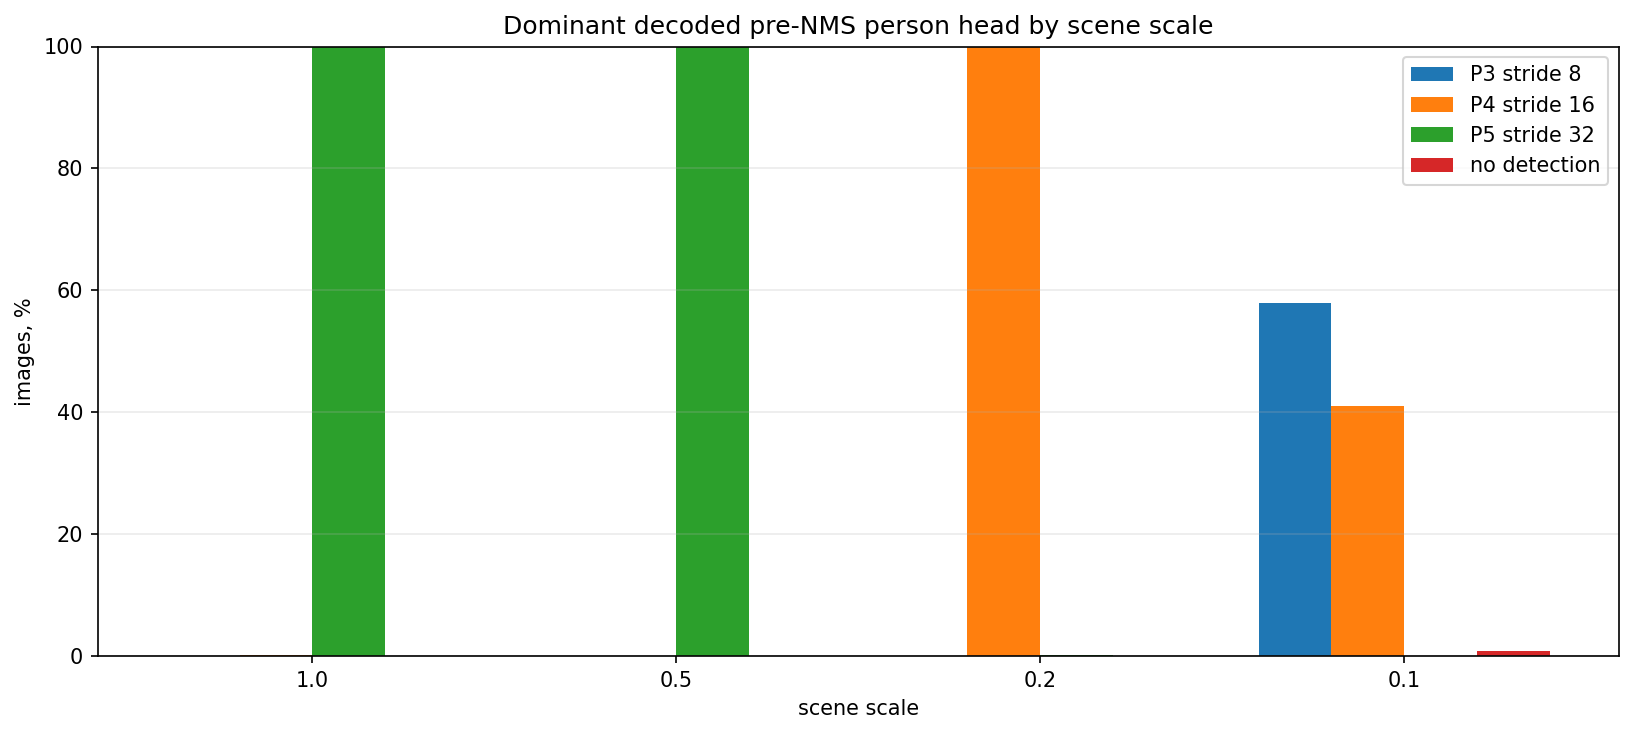

In [7]:
counters, labels = compute_statistics(
    model=model,
    paths=paths,
    scales=scales,
    device=device,
    class_id=class_id,
    conf_thres=conf_thres,
    batch_size=batch_size,
)

stats_png = output_dir / 'head_usage_by_scale.png'
stats_csv = output_dir / 'head_usage_by_scale.csv'
plot_statistics(counters, labels, stats_png)
save_statistics_csv(counters, labels, stats_csv)
display(Image.open(stats_png))


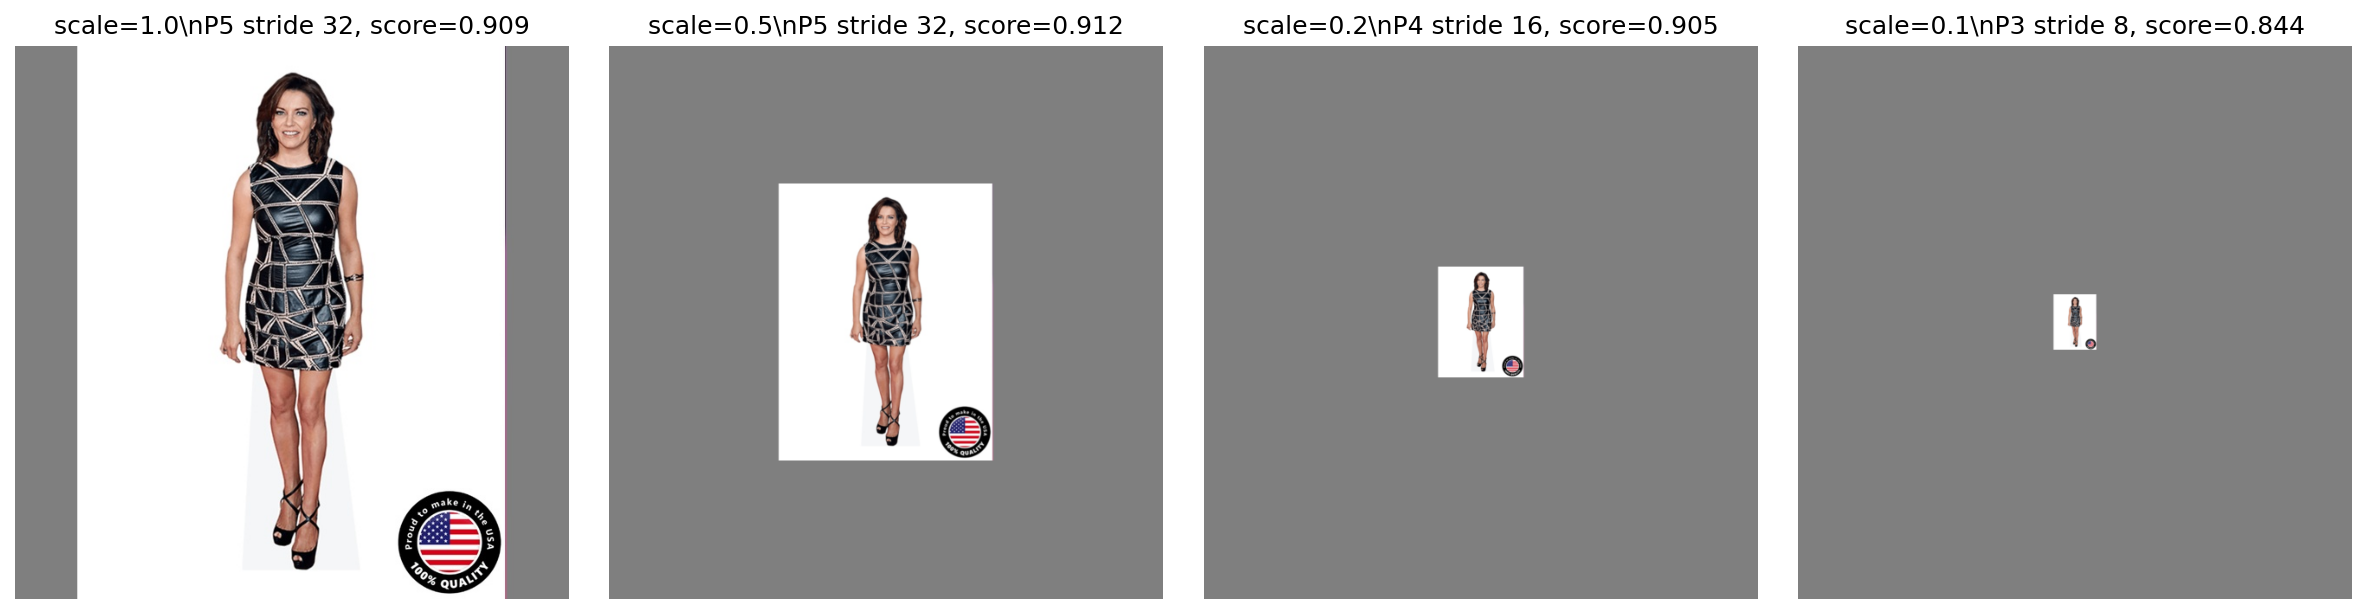

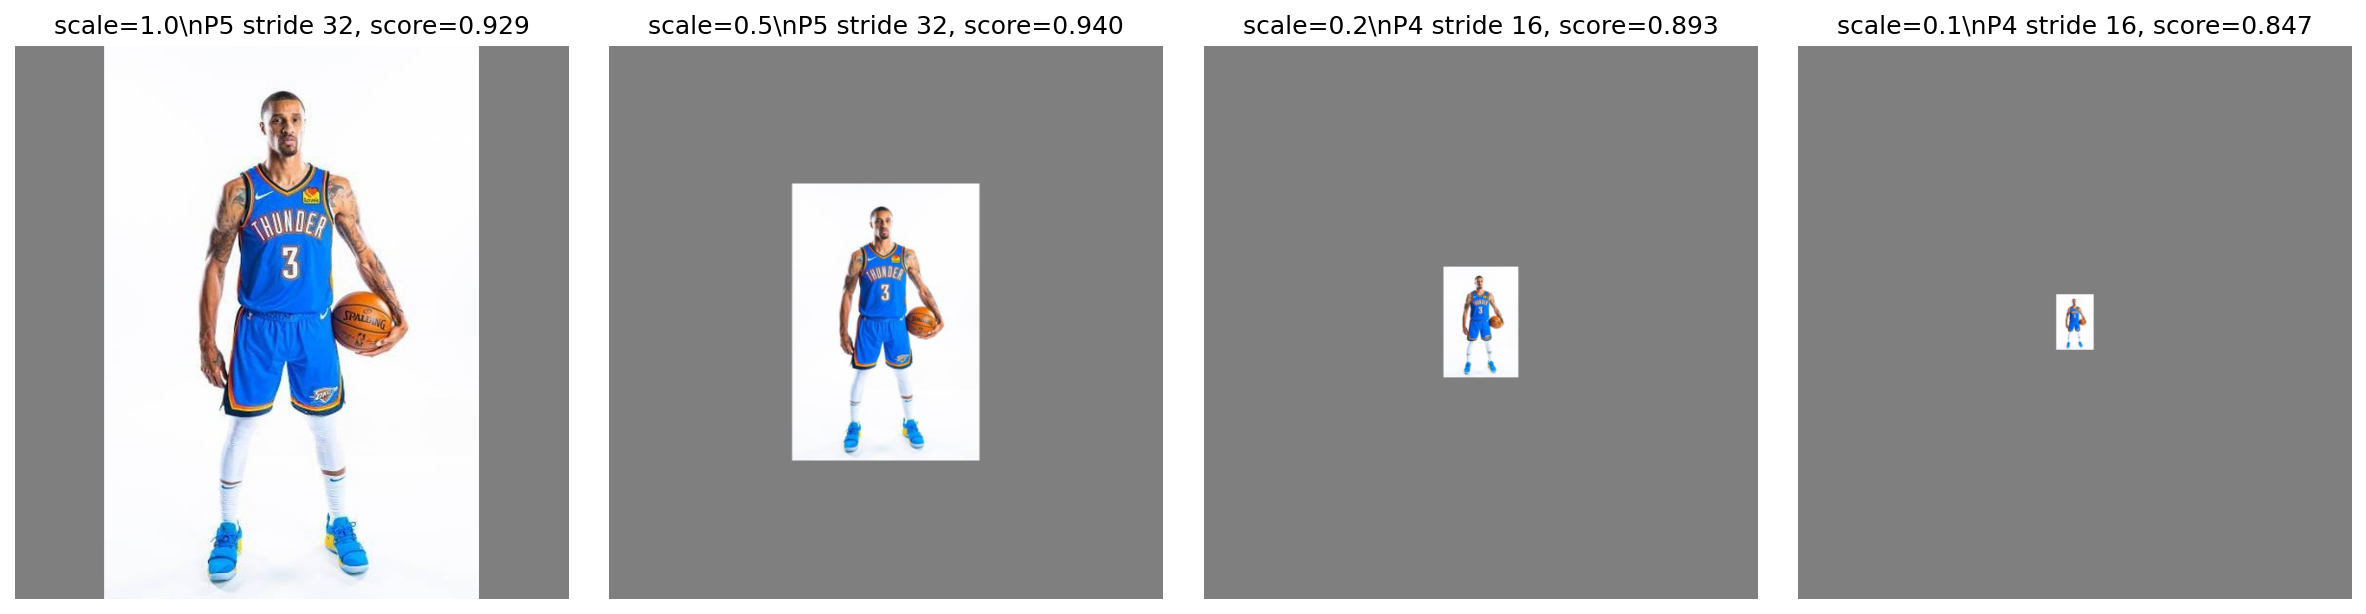

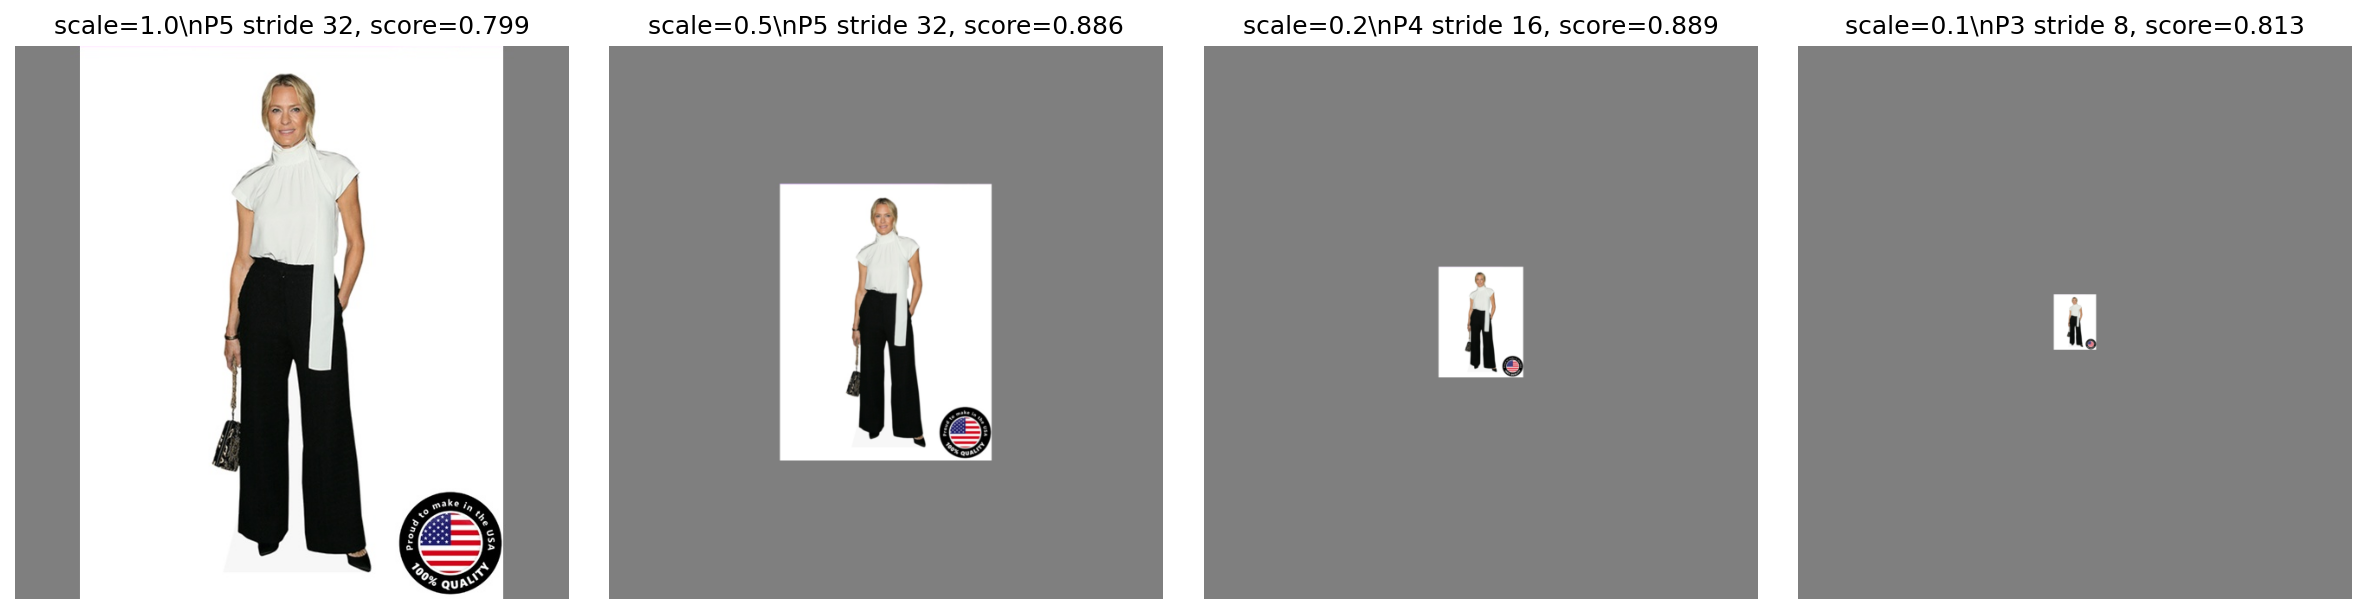

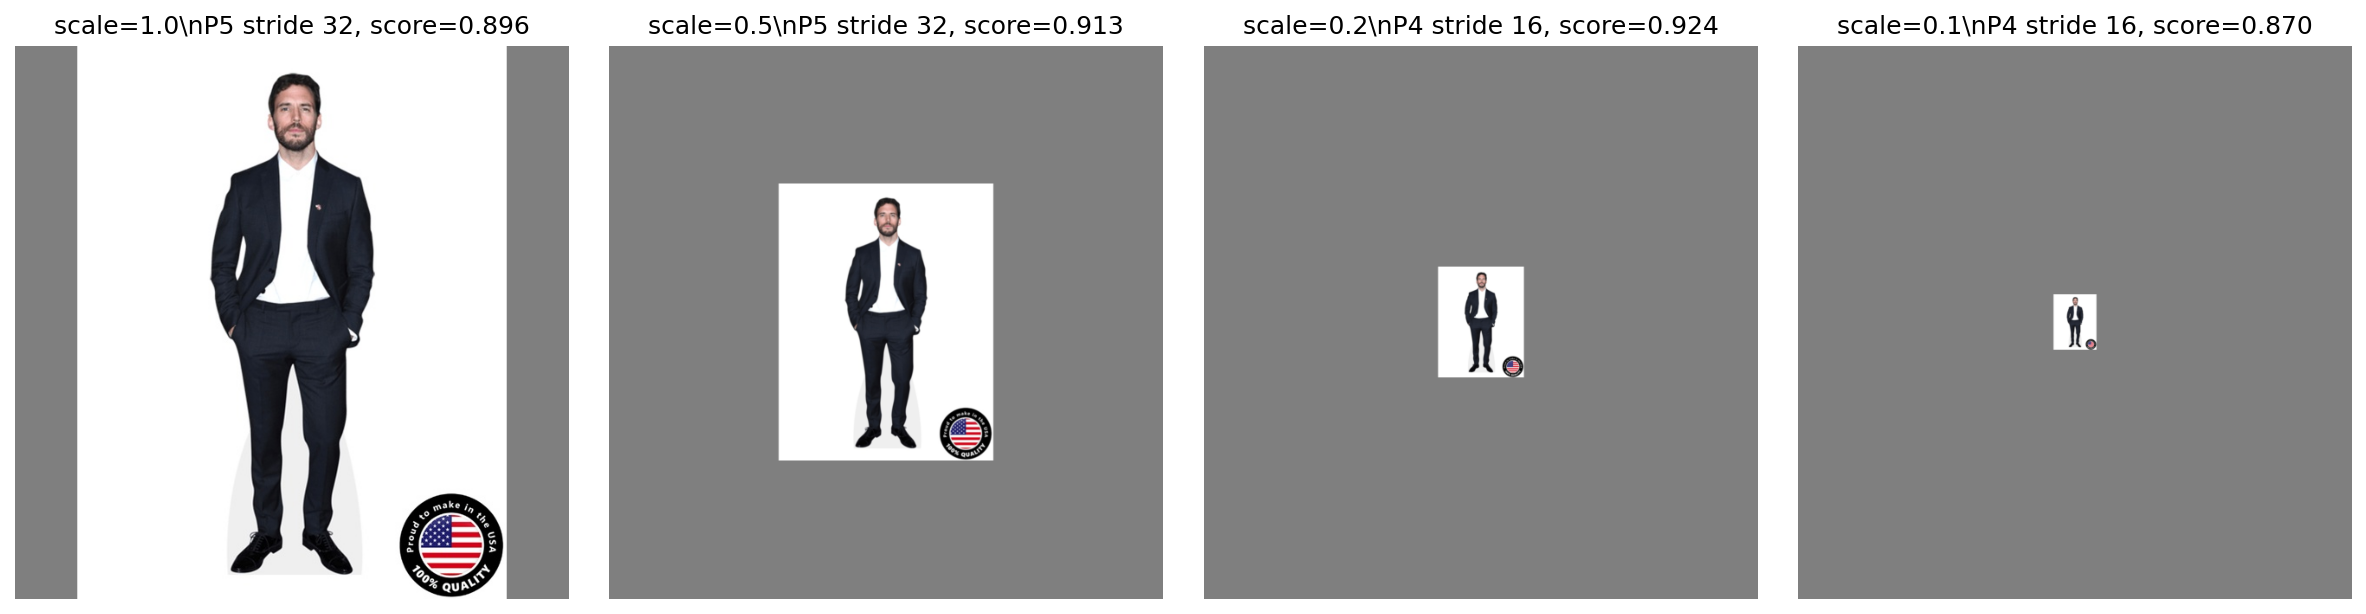

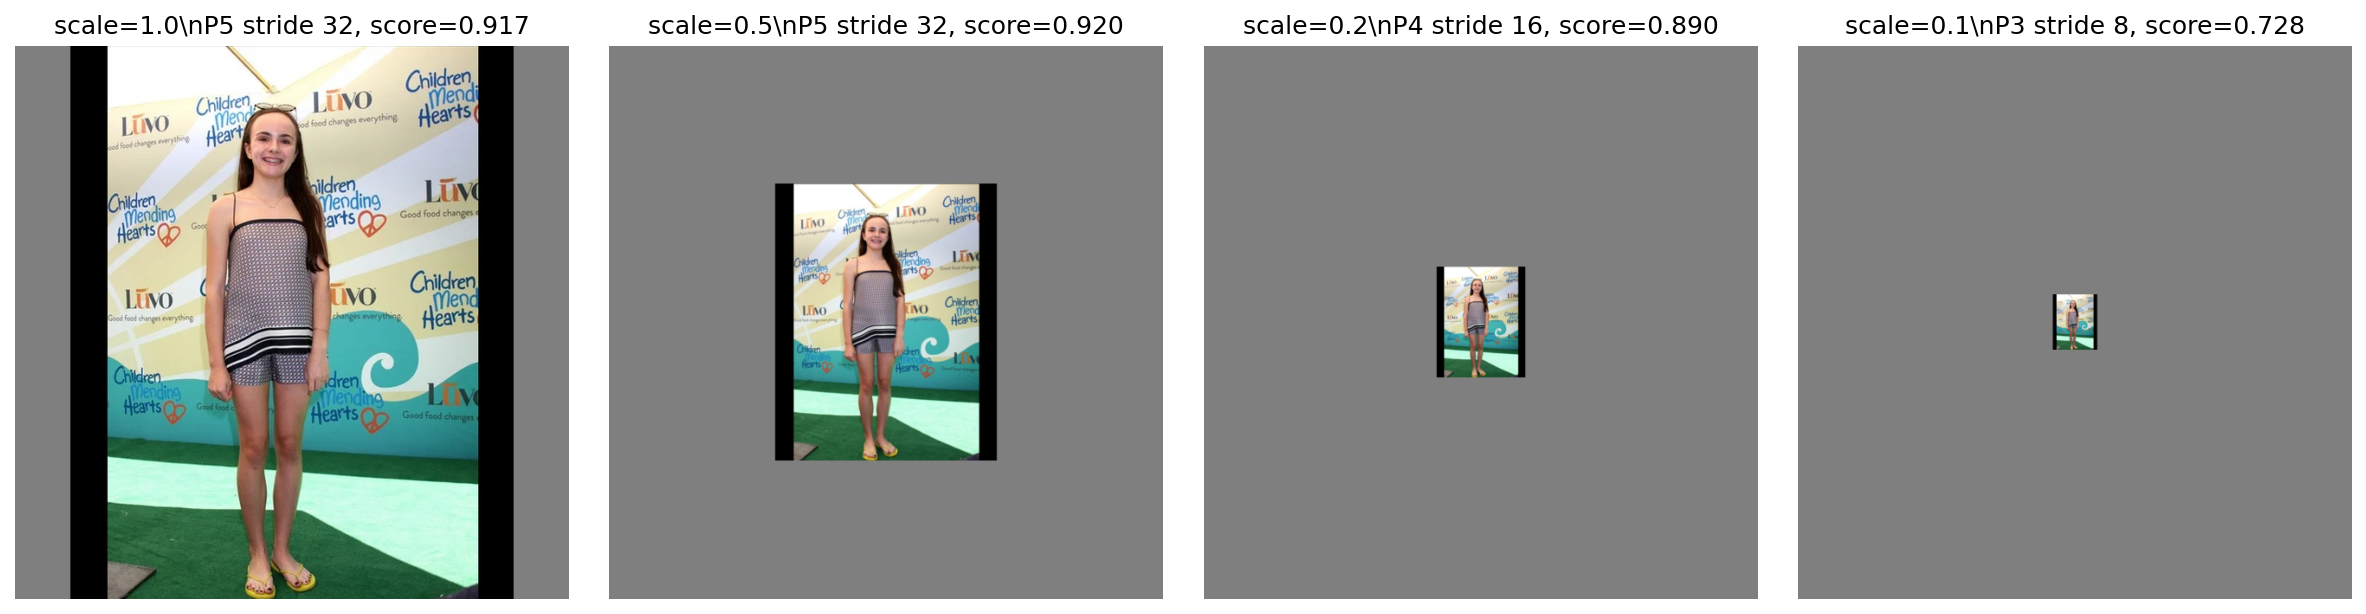

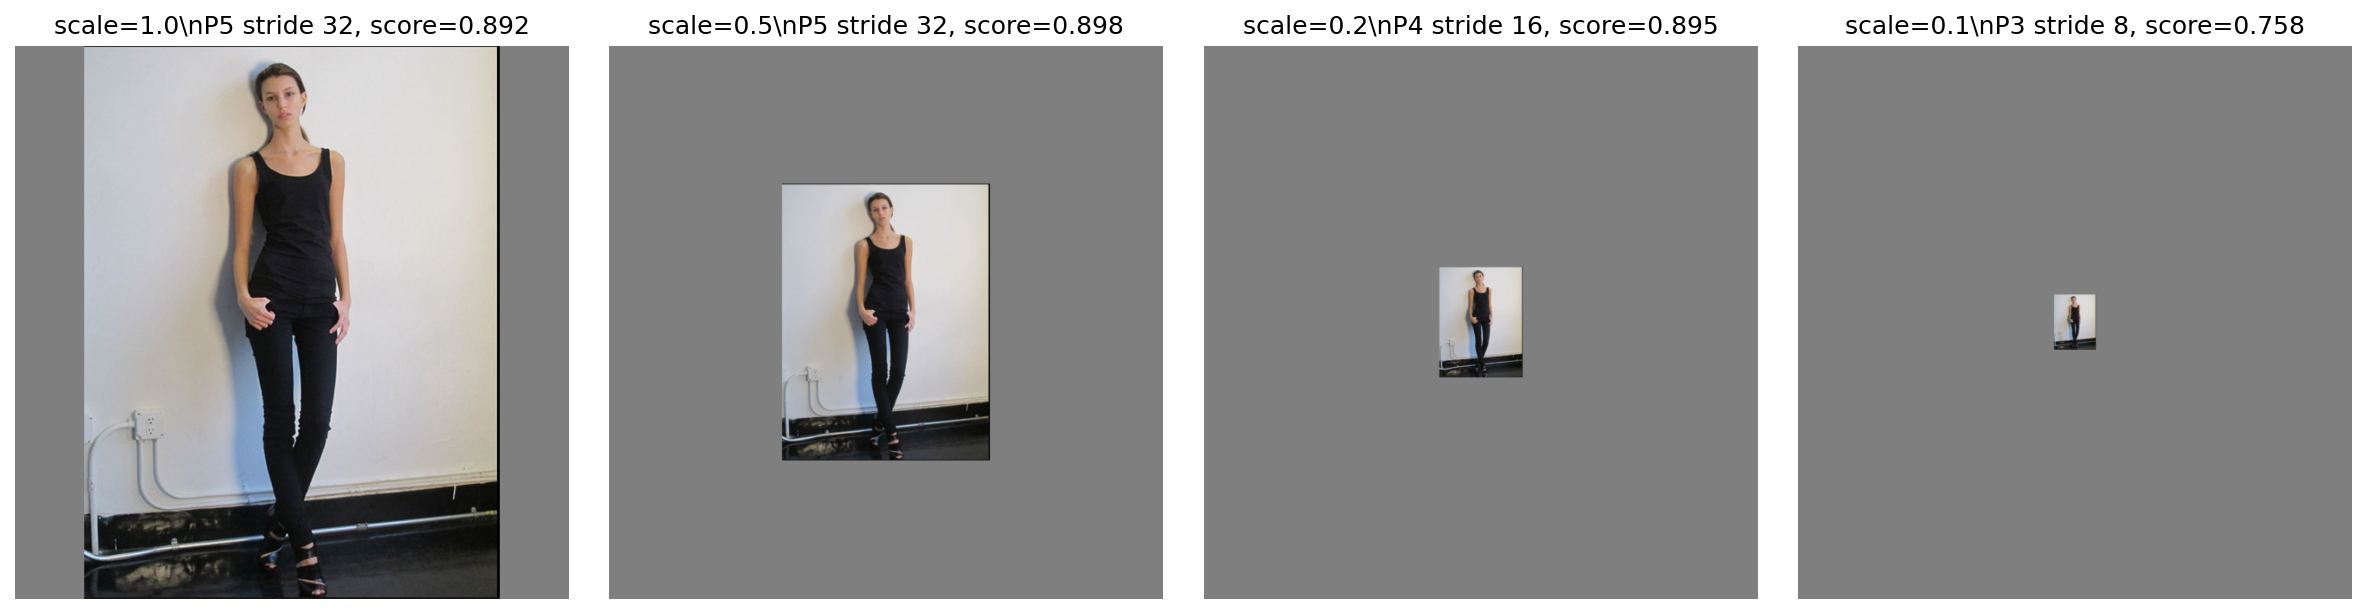

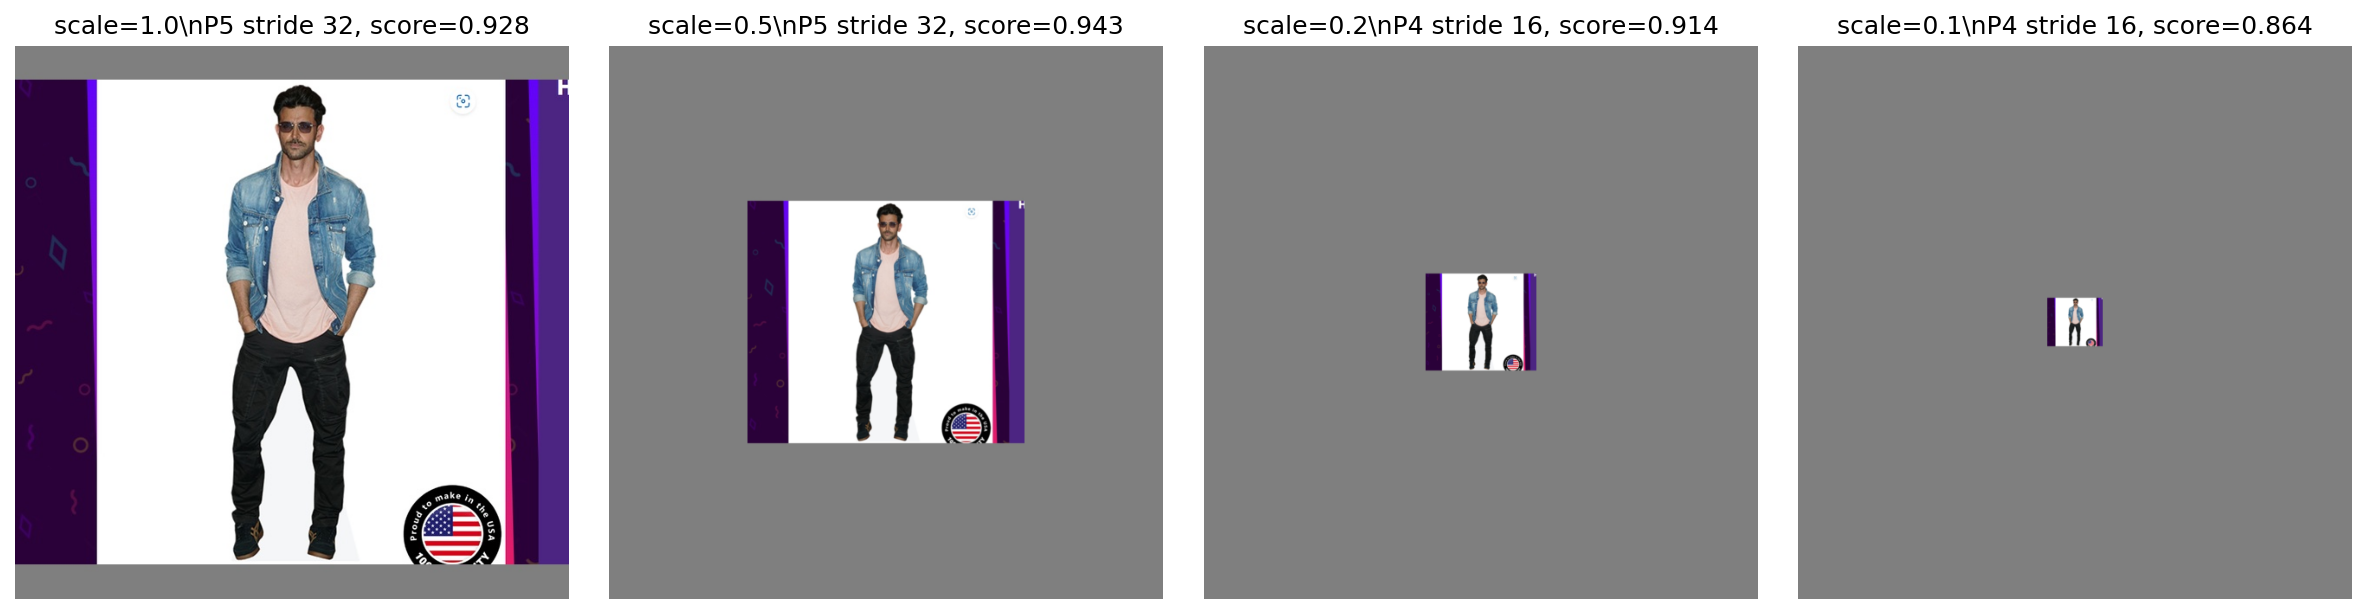

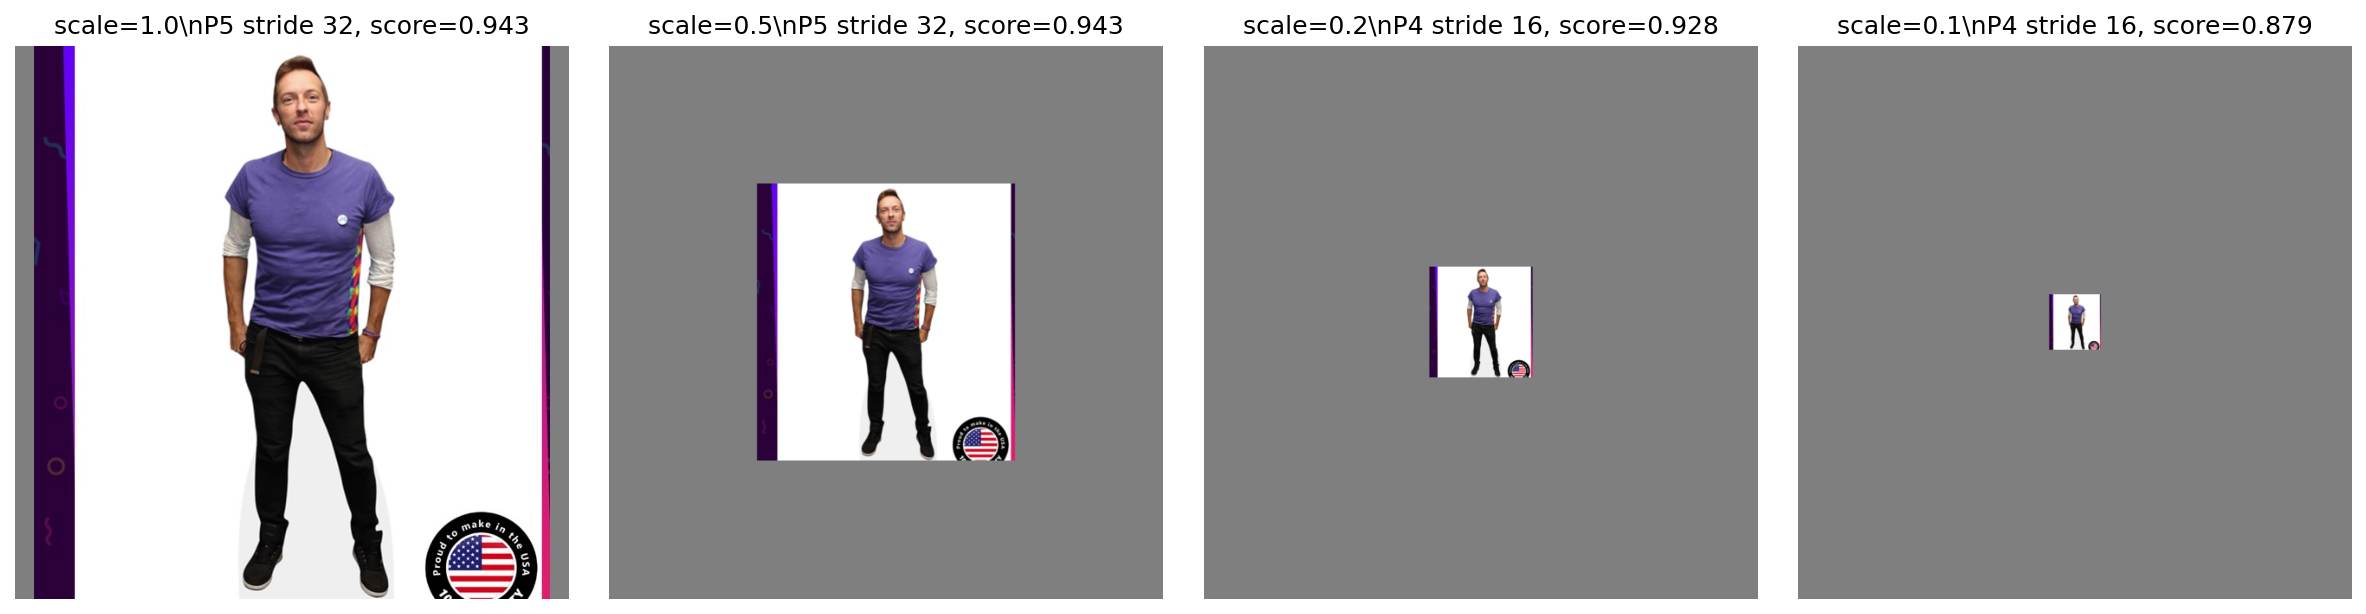

In [8]:
save_visual_examples(
    model=model,
    paths=paths,
    scales=scales,
    device=device,
    class_id=class_id,
    conf_thres=conf_thres,
    output_dir=output_dir / 'examples',
    count=visual_examples,
)

for path in sorted((output_dir / 'examples').glob('*.png'))[:visual_examples]:
    display(Image.open(path))


Single-image four-scale grid. Change `paths[0]` to any image path and run the cell.


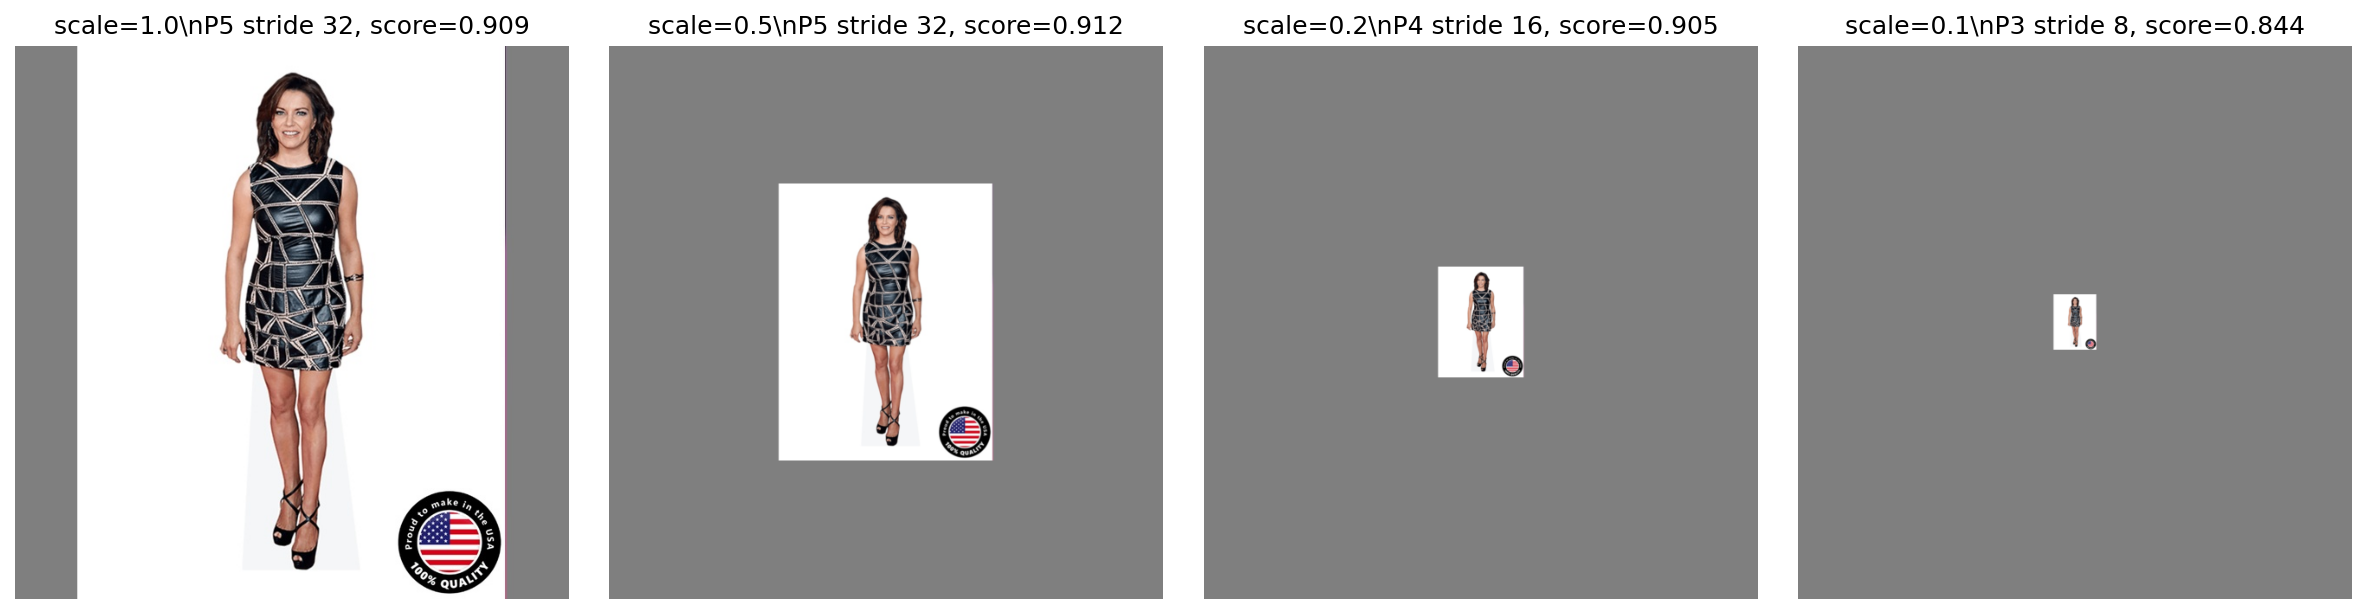

In [9]:
display(Image.open(show_scale_grid(model, paths[0], scales=scales, device=device, class_id=class_id, conf_thres=conf_thres)))
